![image info](https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2023/main/images/banner_1.png)

# Proyecto 1 - Predicción de popularidad en canción

En este proyecto podrán poner en práctica sus conocimientos sobre modelos predictivos basados en árboles y ensambles, y sobre la disponibilización de modelos. Para su desarrollo tengan en cuenta las instrucciones dadas en la "Guía del proyecto 1: Predicción de popularidad en canción".

**Entrega**: La entrega del proyecto deberán realizarla durante la semana 4. Sin embargo, es importante que avancen en la semana 3 en el modelado del problema y en parte del informe, tal y como se les indicó en la guía.

Para hacer la entrega, deberán adjuntar el informe autocontenido en PDF a la actividad de entrega del proyecto que encontrarán en la semana 4, y subir el archivo de predicciones a la competencia de Kaggle cuyo link estará disponible en la sección del Coursera del proyecto.

## Datos para la predicción de popularidad en cancion

En este proyecto se usará el conjunto de datos de datos de popularidad en canciones, donde cada observación representa una canción y se tienen variables como: duración de la canción, acusticidad y tempo, entre otras. El objetivo es predecir qué tan popular es la canción. Para más detalles puede visitar el siguiente enlace: [datos](https://huggingface.co/datasets/maharshipandya/spotify-tracks-dataset).

## Ejemplo predicción conjunto de test para envío a Kaggle

En esta sección encontrarán el formato en el que deben guardar los resultados de la predicción para que puedan subirlos a la competencia en Kaggle.

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Aquí vamos a empezar con la importación de librerías
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib

En esta celda cargamos las librerìas necesarias para el desarrollo de la primera fase de este proyecto. Esto nos permitirá cargar y manipular los datos, construir nuestro pipeline de pre-procesamiento y entrenar nuestros primeros modelos basados en árboles, tambien podremos calibrar los hiperparámetros, evaluar el desempeño predictivo y exportar el modelo para su eventual publicación a través de una API.

In [3]:
# Aquí va nuestra celda para cargar datos de archivo .csv (esta viene sin cambios desde el ejemplo original)
dataTraining = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2026/main/datasets/dataTrain_Spotify.csv')
dataTesting = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2026/main/datasets/dataTest_Spotify.csv', index_col=0)

Aquí cargamos nuestros datos de entrenamiento y prueba de acuerdo con las celdas inicials publicadas para este taller. Este conjunto de datos de entramiento contiene la variable "Popularity", el conjunto de prueba contiene las observaciones sobre las que generaremos las observaciones para la competencia.

In [4]:
# Aquí vamos con la visualización datos de entrenamiento (también sin cambio desde el modelo original)
dataTraining.head()

,Unnamed: 0,track_id,artists,album_name,track_name,duration_ms,explicit,danceability,energy,key,...,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,popularity
0,0,7hUhmkALyQ8SX9mJs5XI3D,Love and Rockets,Love and Rockets,Motorcycle,211533,False,0.305,0.8490,9,...,1,0.0549,0.000058,0.056700,0.4640,0.3200,141.793,4,goth,22
1,1,5x59U89ZnjZXuNAAlc8X1u,Filippa Giordano,Filippa Giordano,"Addio del passato - From ""La traviata""",196000,False,0.287,0.1900,7,...,0,0.0370,0.930000,0.000356,0.0834,0.1330,83.685,4,opera,22
2,2,70Vng5jLzoJLmeLu3ayBQq,Susumu Yokota,Symbol,Purple Rose Minuet,216506,False,0.583,0.5090,1,...,1,0.0362,0.777000,0.202000,0.1150,0.5440,90.459,3,idm,37
3,3,1cRfzLJapgtwJ61xszs37b,Franz Liszt;YUNDI,Relajación y siestas,"Liebeslied (Widmung), S. 566",218346,False,0.163,0.0368,8,...,1,0.0472,0.991000,0.899000,0.1070,0.0387,69.442,3,classical,0
4,4,47d5lYjbiMy0EdMRV8lRou,Scooter,Scooter Forever,The Darkside,173160,False,0.647,0.9210,2,...,1,0.1850,0.000939,0.371000,0.1310,0.1710,137.981,4,techno,27


In [5]:
# Aquí vamos con la visualización datos de test (también sin cambio desde el modelo original)
dataTesting.head()

,track_id,artists,album_name,track_name,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,6KwkVtXm8OUp2XffN5k7lY,Hillsong Worship,No Other Name,No Other Name,440247,False,0.369,0.598,7,-6.984,1,0.0304,0.00511,0.000000,0.176,0.0466,148.014,4,world-music
1,2dp5I5MJ8bQQHDoFaNRFtX,Internal Rot,Grieving Birth,Failed Organum,93933,False,0.171,0.997,7,-3.586,1,0.1180,0.00521,0.801000,0.420,0.0294,122.223,4,grindcore
2,5avw06usmFkFrPjX8NxC40,Zhoobin Askarieh;Ali Sasha,Noise A Noise 20.4-1,"Save the Trees, Pt. 1",213578,False,0.173,0.803,9,-10.071,0,0.1440,0.61300,0.001910,0.195,0.0887,75.564,3,iranian
3,75hT0hvlESnDJstem0JgyR,Bryan Adams,All I Want For Christmas Is You,Merry Christmas,151387,False,0.683,0.511,6,-5.598,1,0.0279,0.40600,0.000197,0.111,0.5980,109.991,3,rock
4,4bY2oZGA5Br3pTE1Jd1IfY,Nogizaka46,バレッタ TypeD,月の大きさ,236293,False,0.555,0.941,9,-3.294,0,0.0481,0.48400,0.000000,0.266,0.8130,92.487,4,j-idol


In [6]:
# Aquí vamos a comenzar con las dimensiones de los conjuntos de datos

print("Dimensiones dataTraining:", dataTraining.shape)
print("Dimensiones dataTesting:", dataTesting.shape)

Dimensiones dataTraining: (79800, 21)
Dimensiones dataTesting: (34200, 19)


El conjunto de datos de entrenamiento cuenta con 79,800 observaciones y 21 variables, mientras que el conjunto de prueba contiene 34,200 observaciones. A partir de la inspección inicial, se identificó que no existen valores faltantes en las variables, lo que simplifica el proceso de preprocesamiento. Las variables incluyen características numéricas relacionadas con propiedades acústicas de las canciones, así como variables categóricas como el género musical

In [7]:
# Aquí vamos con los tipos de datos y valores no nulos

dataTraining.info()

<class 'pandas.DataFrame'>
RangeIndex: 79800 entries, 0 to 79799
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        79800 non-null  int64  
 1   track_id          79800 non-null  str    
 2   artists           79800 non-null  str    
 3   album_name        79800 non-null  str    
 4   track_name        79800 non-null  str    
 5   duration_ms       79800 non-null  int64  
 6   explicit          79800 non-null  bool   
 7   danceability      79800 non-null  float64
 8   energy            79800 non-null  float64
 9   key               79800 non-null  int64  
 10  loudness          79800 non-null  float64
 11  mode              79800 non-null  int64  
 12  speechiness       79800 non-null  float64
 13  acousticness      79800 non-null  float64
 14  instrumentalness  79800 non-null  float64
 15  liveness          79800 non-null  float64
 16  valence           79800 non-null  float64
 17  temp

In [8]:
# Aquí vamos con la visión de valores faltantes

dataTraining.isnull().sum().sort_values(ascending=False)

Unnamed: 0          0
track_id            0
artists             0
album_name          0
track_name          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
popularity          0
dtype: int64

In [9]:
# Aquí vamos a comenzar con las estadísticas descriptivas de la variable objetivo

dataTraining['popularity'].describe()

count    79800.000000
mean        33.265301
std         22.330871
min          0.000000
25%         17.000000
50%         35.000000
75%         50.000000
max        100.000000
Name: popularity, dtype: float64

<Axes: >

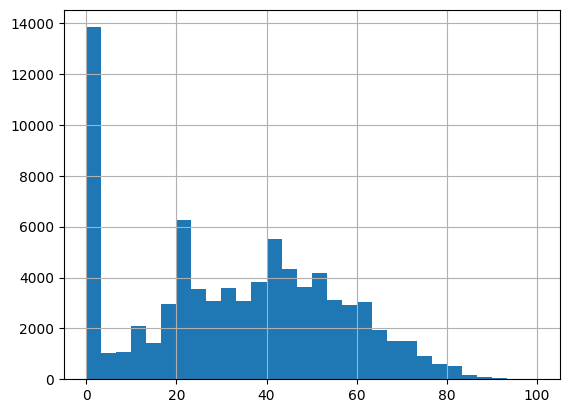

In [10]:
# Aquí veremos la distribución de la variable objetivo

dataTraining['popularity'].hist(bins=30)

Se analizó la variable objetivo popularity, la cual representa el nivel de popularidad de cada canción en una escala numérica. A partir de las estadísticas descriptivas y la visualización de su distribución, se confirmó que se trata de una variable continua, por lo que el problema fue abordado como una tarea de regresión.

In [11]:
# Aquí veremos la separación entre variables predictoras y variable objetivo

X = dataTraining.drop(columns=['popularity'])
y = dataTraining['popularity']

X_test = dataTesting.copy()

In [12]:
# Aquí va la selección de variables para el modelo

numeric_features = [
    'duration_ms', 'danceability', 'energy', 'key', 'loudness',
    'mode', 'speechiness', 'acousticness', 'instrumentalness',
    'liveness', 'valence', 'tempo', 'time_signature']

categorical_features = ['explicit', 'track_genre']

selected_features = numeric_features + categorical_features

X = X[selected_features]
X_test = X_test[selected_features]

Se seleccionaron variables numéricas asociadas a características acústicas de las canciones, tales como danceability, energy, tempo y valence, así como variables categóricas relevantes como explicit y track_genre. Se excluyeron variables como track_id, artists, album_name y track_name, debido a su alta cardinalidad y a que su inclusión requeriría técnicas más complejas de procesamiento de texto. Esta selección permitió construir un modelo inicial más eficiente y fácilmente interpretable.

In [13]:
# Aquí vamos a dividir nuestros datos en los conjuntos de entrenamiento y validación

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [14]:
# Este es nuestro pipeline de preprocesamiento para variables numéricas y categóricas

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)])

In [15]:
# Aquí va nuestro pipeline completo con modelo baseline Random Forest

model_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(
        random_state=42,
        n_estimators=50,
        max_depth=10,
        n_jobs=-1))])

Se construyó un pipeline que integra el preprocesamiento de los datos y el modelo predictivo. Para las variables numéricas se utilizó imputación mediante la mediana, mientras que para las variables categóricas se aplicó imputación por la moda seguida de una codificación one-hot. Este enfoque garantiza que las transformaciones se ajusten únicamente con los datos de entrenamiento y se apliquen de manera consistente a los datos de validación y prueba, evitando fugas de información.

l modelo baseline basado en Random Forest presentó un MAE de 16.99 y un RMSE de 20.84, lo que indica que, en promedio, el error absoluto de las predicciones es cercano a 17 unidades de popularidad. El coeficiente de determinación R² fue de 0.12, lo que sugiere que el modelo logra explicar aproximadamente el 12% de la variabilidad de la variable objetivo. Estos resultados evidencian que, si bien el modelo captura cierta información relevante, su capacidad predictiva inicial es limitada, lo que justifica la necesidad de calibrar los hiperparámetros.

La calibración de hiperparámetros se realizó mediante RandomizedSearchCV, con el fin de explorar diferentes configuraciones del modelo de manera eficiente. Debido al tamaño del conjunto de datos y al costo computacional asociado, la búsqueda se llevó a cabo sobre una muestra de 20,000 observaciones del conjunto de entrenamiento. Este enfoque permitió reducir el tiempo de entrenamiento manteniendo una representación adecuada de los datos.

El modelo calibrado presentó una mejora respecto al baseline en todas las métricas evaluadas. El MAE disminuyó a 16.34 y el RMSE a 20.26, lo que indica una reducción en el error de predicción. Asimismo, el coeficiente R² aumentó a 0.17, lo que refleja una mayor capacidad del modelo para explicar la variabilidad de la popularidad. Estos resultados confirman que la calibración de hiperparámetros contribuyó positivamente al desempeño del modelo.

**Conclusiones**
En comparación con el modelo baseline, el modelo calibrado mostró una mejora consistente en las métricas de desempeño. La reducción en MAE y RMSE indica predicciones más precisas, mientras que el incremento en R² sugiere una mejor capacidad explicativa. Por esta razón, el modelo calibrado fue seleccionado como el modelo final para la generación de predicciones y su posterior disponibilización mediante una API.

A pesar de la mejora obtenida tras la calibración, los valores de R² indican que el modelo aún tiene una capacidad limitada para explicar completamente la variabilidad de la popularidad. Esto sugiere que podrían existir variables adicionales relevantes o relaciones más complejas no capturadas por el modelo actual.

Se logró construir un modelo de regresión basado en Random Forest para predecir la popularidad de canciones, integrando el preprocesamiento y el modelo en un pipeline. La calibración de hiperparámetros permitió mejorar el desempeño respecto al modelo baseline, aunque aún existen oportunidades de mejora. Finalmente, el modelo fue entrenado sobre la totalidad de los datos y preparado para su disponibilización mediante una API.


In [17]:
# Creamos nuevas variables buscando capturar mejor el efecto multiplicativo de los diferentes atributos de las canciones
dataTraining['energy_danceability']= dataTraining['energy']*dataTraining['danceability']
dataTraining['valence_energy']= dataTraining['energy']*dataTraining['valence']
dataTraining['acousticness_energy']= dataTraining['acousticness']*dataTraining['energy']
#Dado que tenemos varios artistas de una misma canción extraeremos el primero para entender cuál es el artista principal y buscar comportamientos asociados a él
dataTraining['main_artist']=dataTraining['artists'].str.split(pat=';').str[0]
#Convertimos la variable duration en ms a minutos y luego aplicamos logaritmo
dataTraining['duration_min']= dataTraining['duration_ms']/60000
dataTraining['duration_log']= np.log1p(dataTraining['duration_min'])



In [18]:
#Creamos variables categóricas para la tonalidad de la canción
dataTraining = pd.get_dummies(dataTraining, columns=['key'], drop_first=True)

In [19]:
#Creamos X, y desde nuestro df dataTraining
X = dataTraining.drop(columns=['popularity'])
y = dataTraining['popularity']

In [20]:
# Creamos variables adicionales en función de la popularidad del artista y del género, para incluir estos atributos dentro de nuestro predictor,
# al correr el riesgo de DataLeakage no podemos calcularlos en el df de entrada sino debemos calcularlos en cada validación del CV
from sklearn.base import BaseEstimator, TransformerMixin

class AgregadosPorGrupo(BaseEstimator, TransformerMixin):

    def __init__(self):
        pass


    def fit(self, X, y):
        df_temp=pd.concat([X,y], axis=1)
        conteo = df_temp.groupby('main_artist')['popularity'].count()
        artistas_validos = conteo[conteo >= 5].index
        df_artistas = df_temp[df_temp['main_artist'].isin(artistas_validos)]
        self.artist_means_ =df_artistas.groupby('main_artist')['popularity'].mean()
        self.artist_stds_ =df_artistas.groupby('main_artist')['popularity'].std()
        self.artist_counts_ =df_artistas.groupby('main_artist')['popularity'].count()
        self.track_genre_means_ =df_temp.groupby('track_genre')['popularity'].mean()
        self.track_genre_stds_ =df_temp.groupby('track_genre')['popularity'].std()
        self.track_genre_counts_ =df_temp.groupby('track_genre')['popularity'].count()
        self.global_mean_ = y.mean()
        self.global_std_ = y.std()
        self.global_count_ = y.count()
        return self
    
    def transform(self, X):
        X = X.copy()
        X['artist_mean_popularity'] = X['main_artist'].map(self.artist_means_).fillna(self.global_mean_)
        X['artist_std_popularity'] = X['main_artist'].map(self.artist_stds_).fillna(self.global_std_)
        X['artist_count_popularity'] = X['main_artist'].map(self.artist_counts_).fillna(1)
        
        X['track_genre_mean_popularity'] = X['track_genre'].map(self.track_genre_means_).fillna(self.global_mean_)
        X['track_genre_std_popularity'] = X['track_genre'].map(self.track_genre_stds_).fillna(self.global_std_)
        X['track_genre_count_popularity'] = X['track_genre'].map(self.track_genre_counts_).fillna(1)
        X = X.drop(columns=['main_artist', 'album_name', 'track_genre'])
        return X

In [21]:
#Eliminamos las features que hemos visto menos importantes con el objetivo de tener un modelo más limpio
features = X.drop(columns=['track_id', 'artists', 'track_name', 'duration_ms', 'Unnamed: 0','duration_log','mode','explicit','time_signature']).columns.tolist()
features = [f for f in features if not f.startswith('key_')]

In [22]:
#Instalamos el regresor Light Gradient Boosting
!pip install lightgbm
from lightgbm import LGBMRegressor
from sklearn.pipeline import Pipeline

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 1.5/1.5 MB 18.7 MB/s  0:00:00


In [23]:
#Creamos el pipeline incluyendo los cálculos de variables adicionales que hemos hablado de popularidad media, std y conteo por artista y por género
pipeline = Pipeline(steps=[
    ('agregados', AgregadosPorGrupo()),
    ('modelo', LGBMRegressor())
])

In [24]:
#Corremos el modelo sin especificar hiperparámetros
from sklearn.model_selection import cross_val_score
import numpy as np

scores = cross_val_score(
    pipeline,
    X[features],
    y,
    cv=5,
    scoring='neg_root_mean_squared_error'
)

print("RMSE por fold:", -scores)
print("RMSE promedio:", -scores.mean())

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005414 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4205
[LightGBM] [Info] Number of data points in the train set: 63840, number of used features: 19
[LightGBM] [Info] Start training from score 33.222102
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008880 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4211
[LightGBM] [Info] Number of data points in the train set: 63840, number of used features: 19
[LightGBM] [Info] Start training from score 33.257613
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005329 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4216
[LightGBM] [Info] Number of data points in the train set: 63840, number of used features: 19
[LightGBM] [Info] Start t

In [27]:
!pip install xgboost

  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)


In [28]:
#Definimos un pipeline aparte para calcular el modelo con XGB
from xgboost import XGBRegressor

pipeline_xgb = Pipeline(steps=[
    ('agregados', AgregadosPorGrupo()),
    ('modelo', XGBRegressor())
])

In [29]:
#Corremos también el modelo XGBoost para tener una idea de qué modelo tiene mejor desempeño

scores = cross_val_score(
    pipeline_xgb,
    X[features],
    y,
    cv=5,
    scoring='neg_root_mean_squared_error'
)

print("RMSE por fold:", -scores)
print("RMSE promedio:", -scores.mean())

RMSE por fold: [14.69898891 15.01761627 14.38467598 14.59965992 14.66798401]
RMSE promedio: 14.6737850189209


In [30]:
#Dado que tuvimos un mejor resultado con el XGBoost para este modelo haremos el ajuste de hiperparámetros
param_dist = {
    'modelo__n_estimators': [100, 200, 300, 500],
    'modelo__max_depth': [3, 5, 7, 10],
    'modelo__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'modelo__num_leaves': [31, 63, 127, 255]
}

from sklearn.model_selection import RandomizedSearchCV

search = RandomizedSearchCV(
    estimator=pipeline_xgb,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    verbose=1
)
search.fit(X[features], y)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'modelo__learning_rate': [0.01, 0.05, ...], 'modelo__max_depth': [3, 5, ...], 'modelo__n_estimators': [100, 200, ...], 'modelo__num_leaves': [31, 63, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variousc

In [31]:
#Imprimimos los resultados del fine tuning de parámetros
print("Mejores hiperparámetros:", search.best_params_)
print("Mejor RMSE:", -search.best_score_)

Mejores hiperparámetros: {'modelo__num_leaves': 63, 'modelo__n_estimators': 300, 'modelo__max_depth': 10, 'modelo__learning_rate': 0.1}
Mejor RMSE: 13.792486381530761


In [32]:
search.best_estimator_.named_steps['modelo']

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_met

In [33]:
#Preparamos los datos de Testing para crear la misma combinación de variables que hicimos en los datos de training
dataTesting['energy_danceability']= dataTesting['energy']*dataTraining['danceability']
dataTesting['valence_energy']= dataTesting['energy']*dataTesting['valence']
dataTesting['acousticness_energy']= dataTesting['acousticness']*dataTesting['energy']
dataTesting['main_artist']=dataTesting['artists'].str.split(pat=';').str[0]

dataTesting['duration_min']= dataTesting['duration_ms']/60000
dataTesting['duration_log']= np.log1p(dataTesting['duration_min'])

dataTesting = pd.get_dummies(dataTesting, columns=['key'], drop_first=True)

X_test = dataTesting

In [34]:
#Corremos el modelo para los datos de testing

test_pred = search.best_estimator_.predict(X_test[features])
y_pred = pd.DataFrame(test_pred, index=X_test[features].index, columns=['Popularity'])
y_pred.head()

,Popularity
0,46.209698
1,12.916492
2,-1.401557
3,4.283585
4,26.473936


In [35]:
#Exportamos nuestra predicción
y_pred.to_csv('test_submission_file_gmb_limpiando features-1.csv', index_label='ID')